# 04 Model Interpretation

目标：读取训练后的评估和SHAP输出，形成论文第五章所需的解释性分析。不在Notebook中重复训练模型。


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

outputs = PROJECT_ROOT / "outputs"
experiment = "iv_002_050"


In [2]:
metrics_path = outputs / "tables/all_metrics_train_valid_test.csv"
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    display(metrics[metrics["Scheme"] == experiment])
else:
    print("No metrics found. Run scripts/train.py first.")


,AUC,PR_AUC,Precision,Recall,F1,KS,Threshold,Scheme,Model,Split
9,0.860862,0.387108,0.441785,0.373229,0.404623,0.564691,0.876470,iv_002_050,woe_lr,Train
10,0.829971,0.327126,0.371594,0.358646,0.365005,0.517405,0.876470,iv_002_050,woe_lr,Valid
11,0.835335,0.302776,0.332692,0.392799,0.360256,0.511742,0.876470,iv_002_050,woe_lr,Test
12,0.883777,0.503217,0.466382,0.487619,0.476764,0.608419,0.718106,iv_002_050,random_forest,Train
13,0.857519,0.414881,0.441910,0.407627,0.424077,0.551948,0.718106,iv_002_050,random_forest,Valid
14,0.859634,0.440043,0.397953,0.441453,0.418576,0.558066,0.718106,iv_002_050,random_forest,Test
15,0.947426,0.746402,0.794764,0.634750,0.705801,0.758504,0.233558,iv_002_050,xgboost,Train
16,0.905072,0.549393,0.637403,0.458251,0.533180,0.654120,0.233558,iv_002_050,xgboost,Valid
17,0.896947,0.514422,0.572345,0.463185,0.512011,0.638826,0.233558,iv_002_050,xgboost,Test


In [3]:
topk_path = outputs / "tables/all_topk_train_valid_test_with_lift.csv"
if topk_path.exists():
    topk = pd.read_csv(topk_path)
    display(topk[(topk["Scheme"] == experiment) & (topk["Split"] == "Test")])
else:
    print("No TopK table found. Run scripts/train.py first.")


,TopRate,TopN,Precision,RecallCapture,Lift,Scheme,Model,Split
44,0.01,885,0.589831,0.169316,16.947057,iv_002_050,woe_lr,Test
45,0.03,2657,0.388784,0.335063,11.170583,iv_002_050,woe_lr,Test
46,0.05,4429,0.293972,0.422316,8.446414,iv_002_050,woe_lr,Test
47,0.10,8858,0.185143,0.531949,5.319554,iv_002_050,woe_lr,Test
56,0.01,885,0.835028,0.239702,23.992098,iv_002_050,random_forest,Test
57,0.03,2657,0.468197,0.403503,13.452279,iv_002_050,random_forest,Test
58,0.05,4429,0.333710,0.479403,9.588172,iv_002_050,random_forest,Test
59,0.10,8858,0.203206,0.583847,5.838535,iv_002_050,random_forest,Test
68,0.01,885,0.873446,0.250730,25.095929,iv_002_050,xgboost,Test
69,0.03,2657,0.546481,0.470970,15.701535,iv_002_050,xgboost,Test


In [4]:
shap_path = outputs / experiment / "shap/shap_importance.csv"
if shap_path.exists():
    shap_imp = pd.read_csv(shap_path)
    display(shap_imp.head(30))
else:
    print("No SHAP table found. Run scripts/explain.py first.")


,Feature,MeanSHAP,MeanAbsSHAP,MedianSHAP,PositiveSHAPRate,NegativeSHAPRate,SHAPShare,BaseFeature,FeatureCategory,RiskMechanism,FeatureType
0,C13,-0.214554,0.445251,-0.201189,0.3584,0.6416,0.077065,C13,行为计数统计特征,批量聚集与实体关联异常,numeric
1,C5,-0.108177,0.261518,0.103515,0.6212,0.3788,0.045264,C5,行为计数统计特征,批量聚集与实体关联异常,numeric
2,C1,-0.068787,0.220223,-0.150957,0.1928,0.8072,0.038117,C1,行为计数统计特征,批量聚集与实体关联异常,numeric
3,card6,-0.069854,0.207556,-0.169189,0.2358,0.7642,0.035925,card6,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
4,TransactionAmt_log,-0.047683,0.177295,-0.085564,0.2706,0.7294,0.030687,TransactionAmt_log,交易基础特征,交易场景异常,numeric
5,C2,-0.012591,0.149733,-0.091310,0.4406,0.5594,0.025916,C2,行为计数统计特征,批量聚集与实体关联异常,numeric
6,P_emaildomain,-0.000018,0.143051,0.064867,0.6830,0.3170,0.024760,P_emaildomain,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
7,C11,-0.017751,0.132676,-0.068359,0.3528,0.6472,0.022964,C11,行为计数统计特征,批量聚集与实体关联异常,numeric
8,card2,-0.019381,0.128571,-0.034878,0.3788,0.6212,0.022253,card2,支付工具与身份代理特征,支付身份与联系方式异常,categorical_encoded
9,M4,-0.039343,0.114835,-0.093962,0.4450,0.5550,0.019876,M4,身份匹配一致性特征,身份一致性异常,categorical_encoded


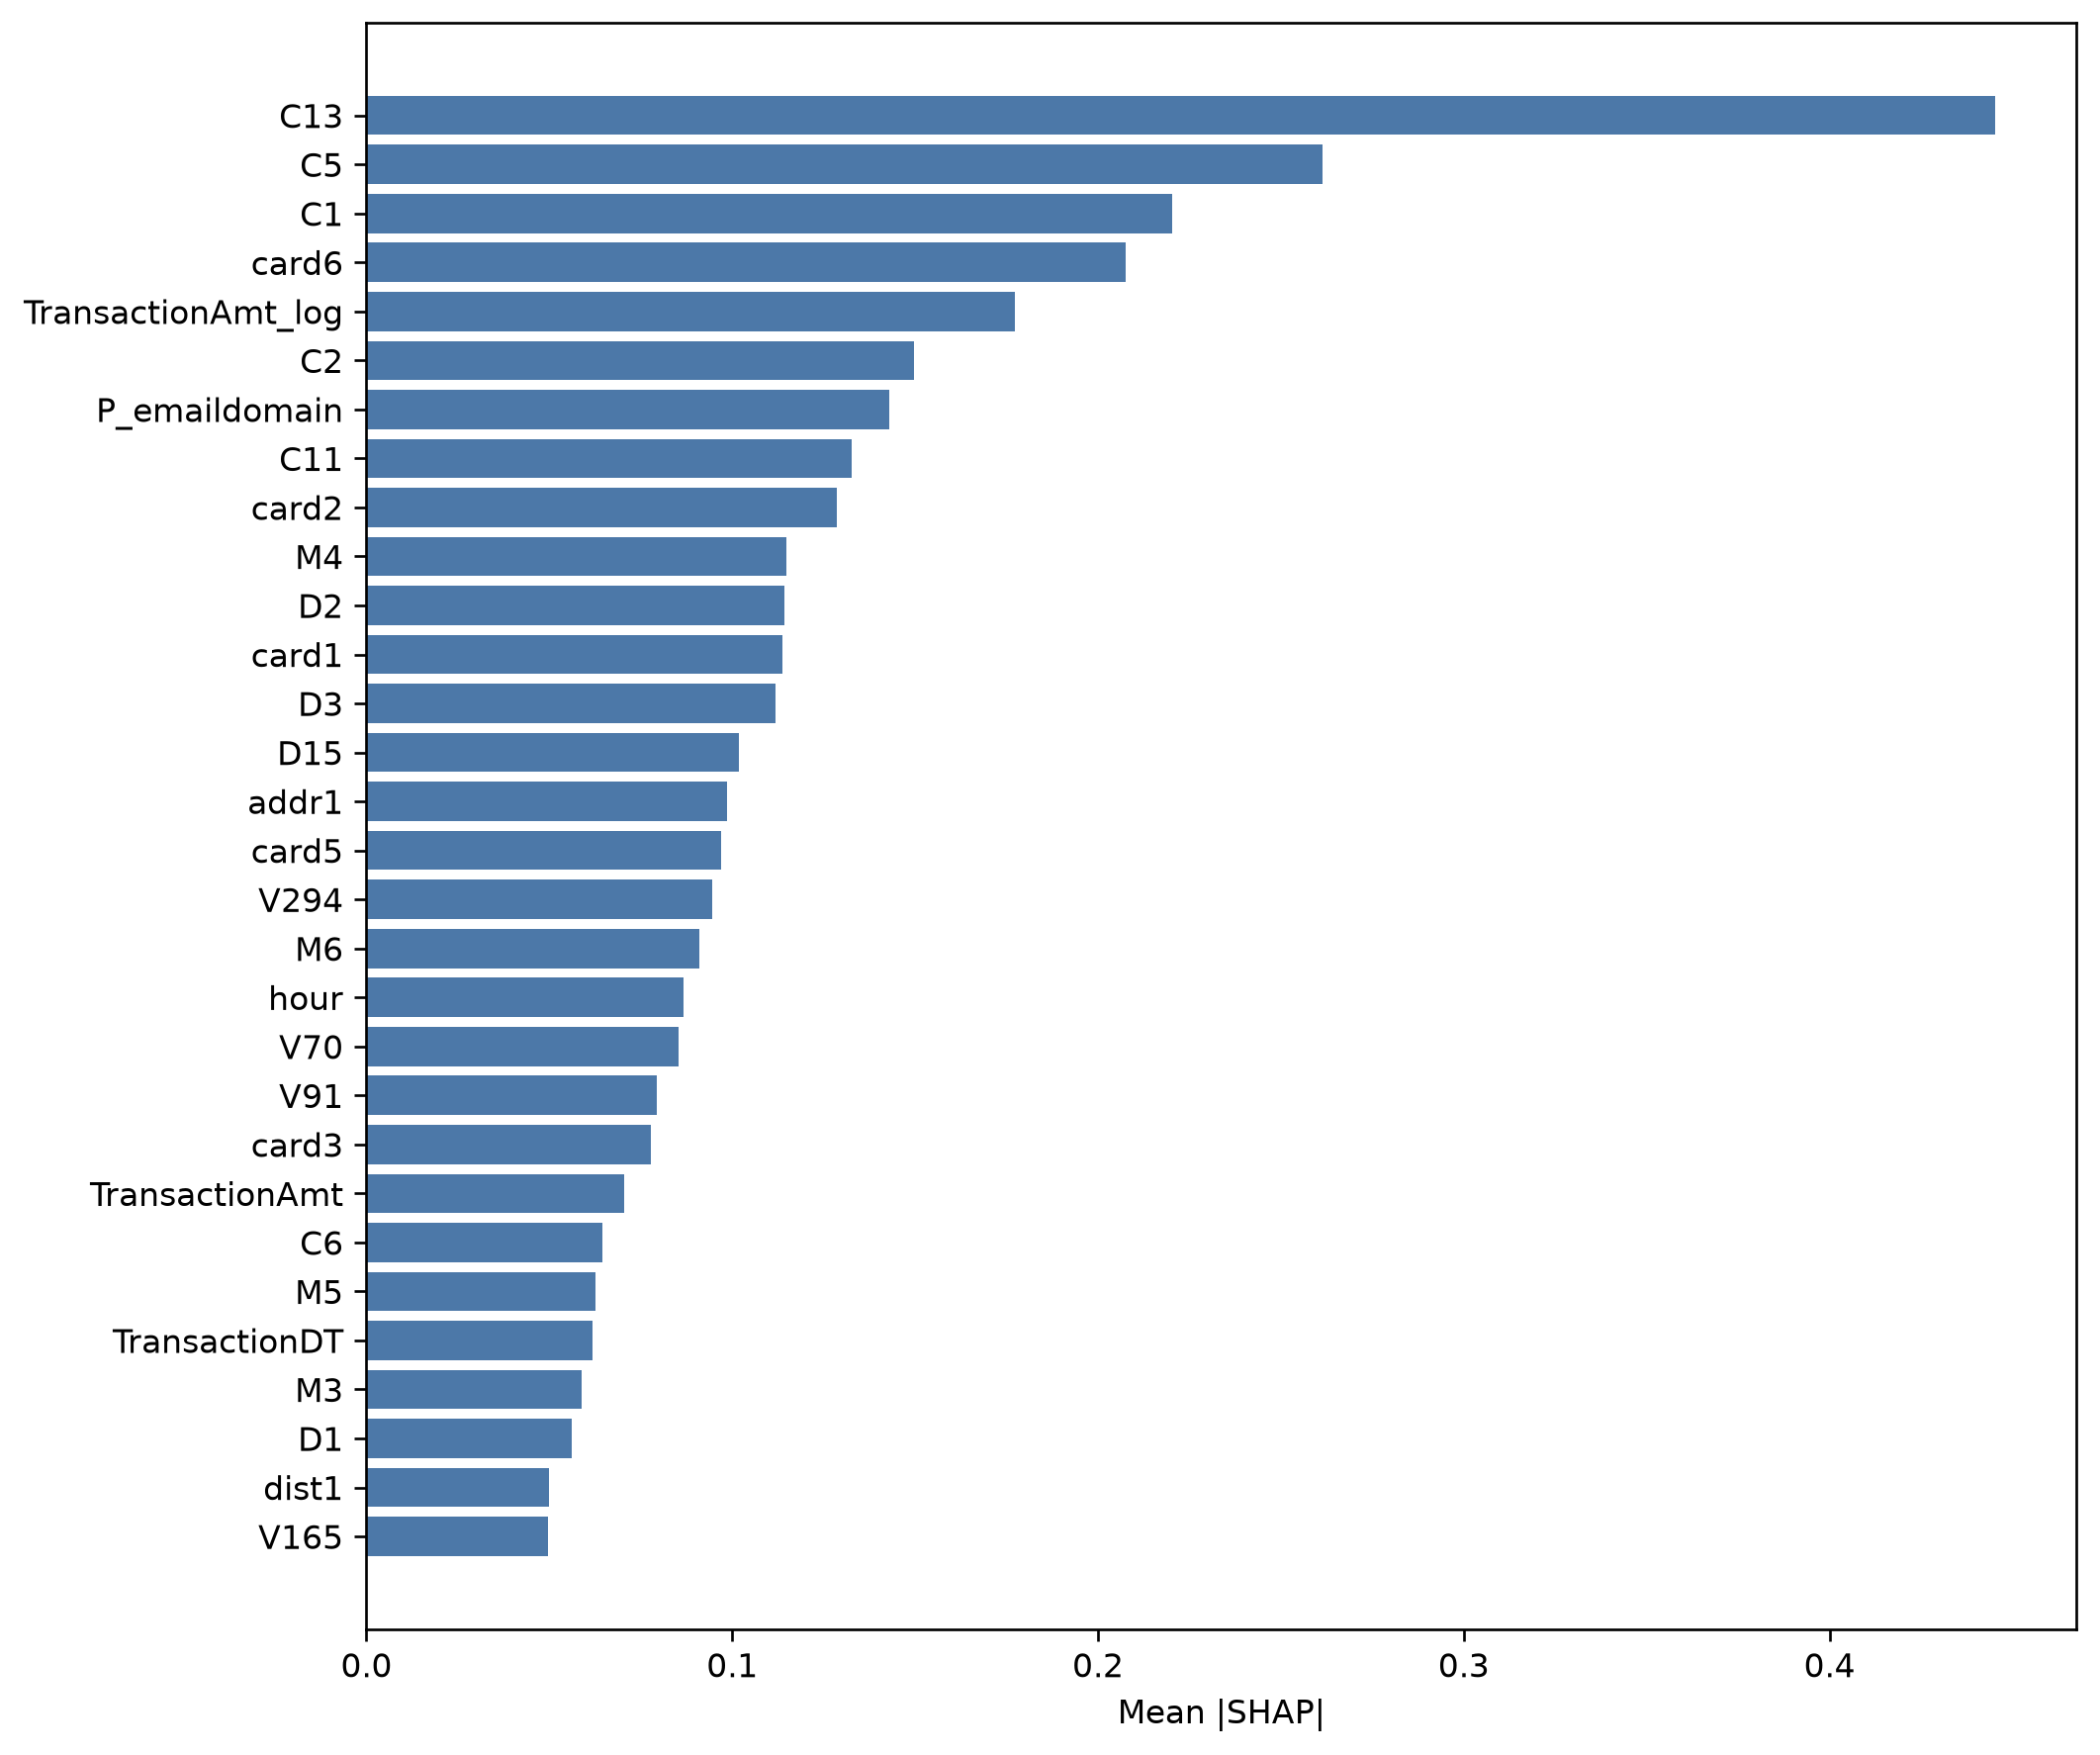

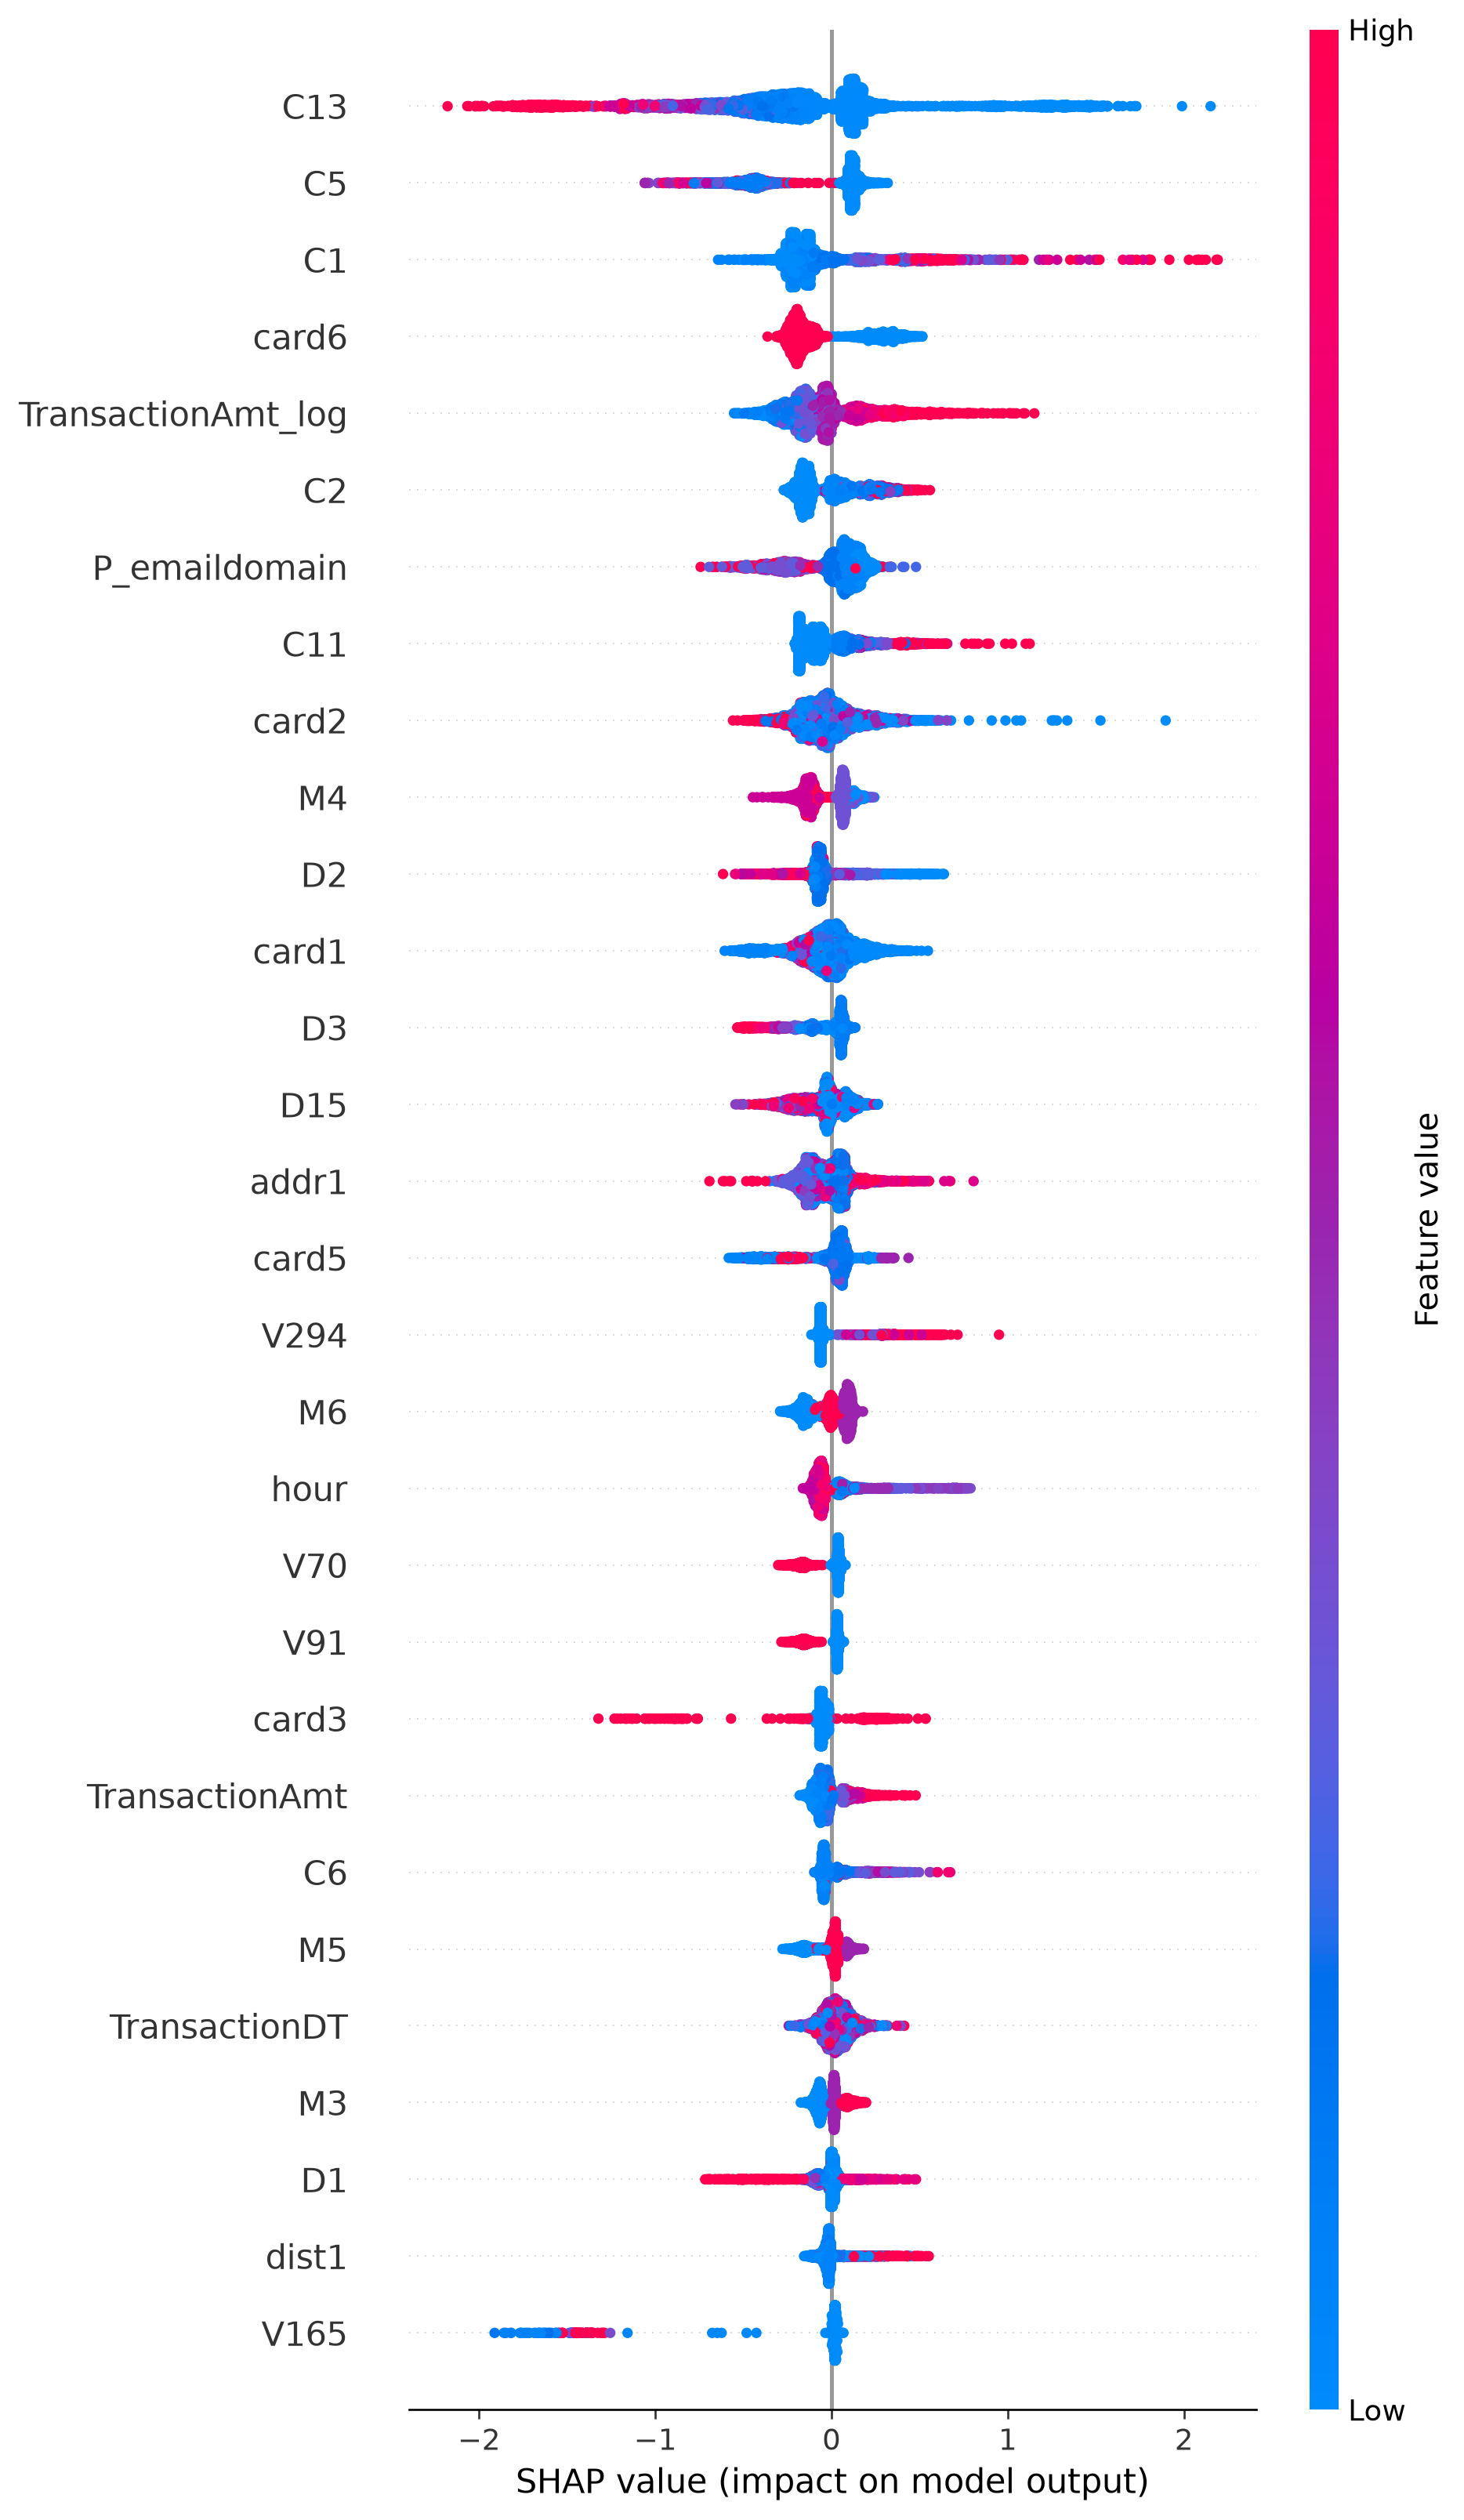

In [5]:
for fig_name in ["shap_importance_top30.png", "shap_summary_top30.png"]:
    fig_path = outputs / experiment / "shap" / fig_name
    if fig_path.exists():
        display(Image(filename=str(fig_path)))
    else:
        print(f"Missing: {fig_path}")
